In [ ]:

!pip install HilbertCurve

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Model run at 95.83 %
model run took 14 seconds, finished 2023-04-17 12:36:32


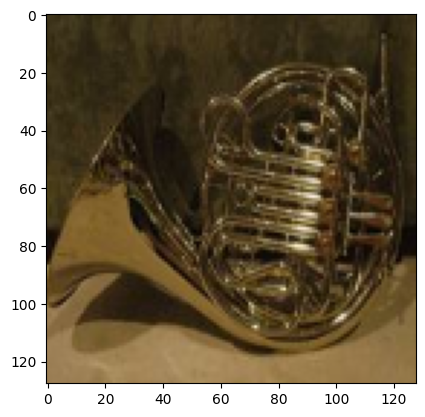

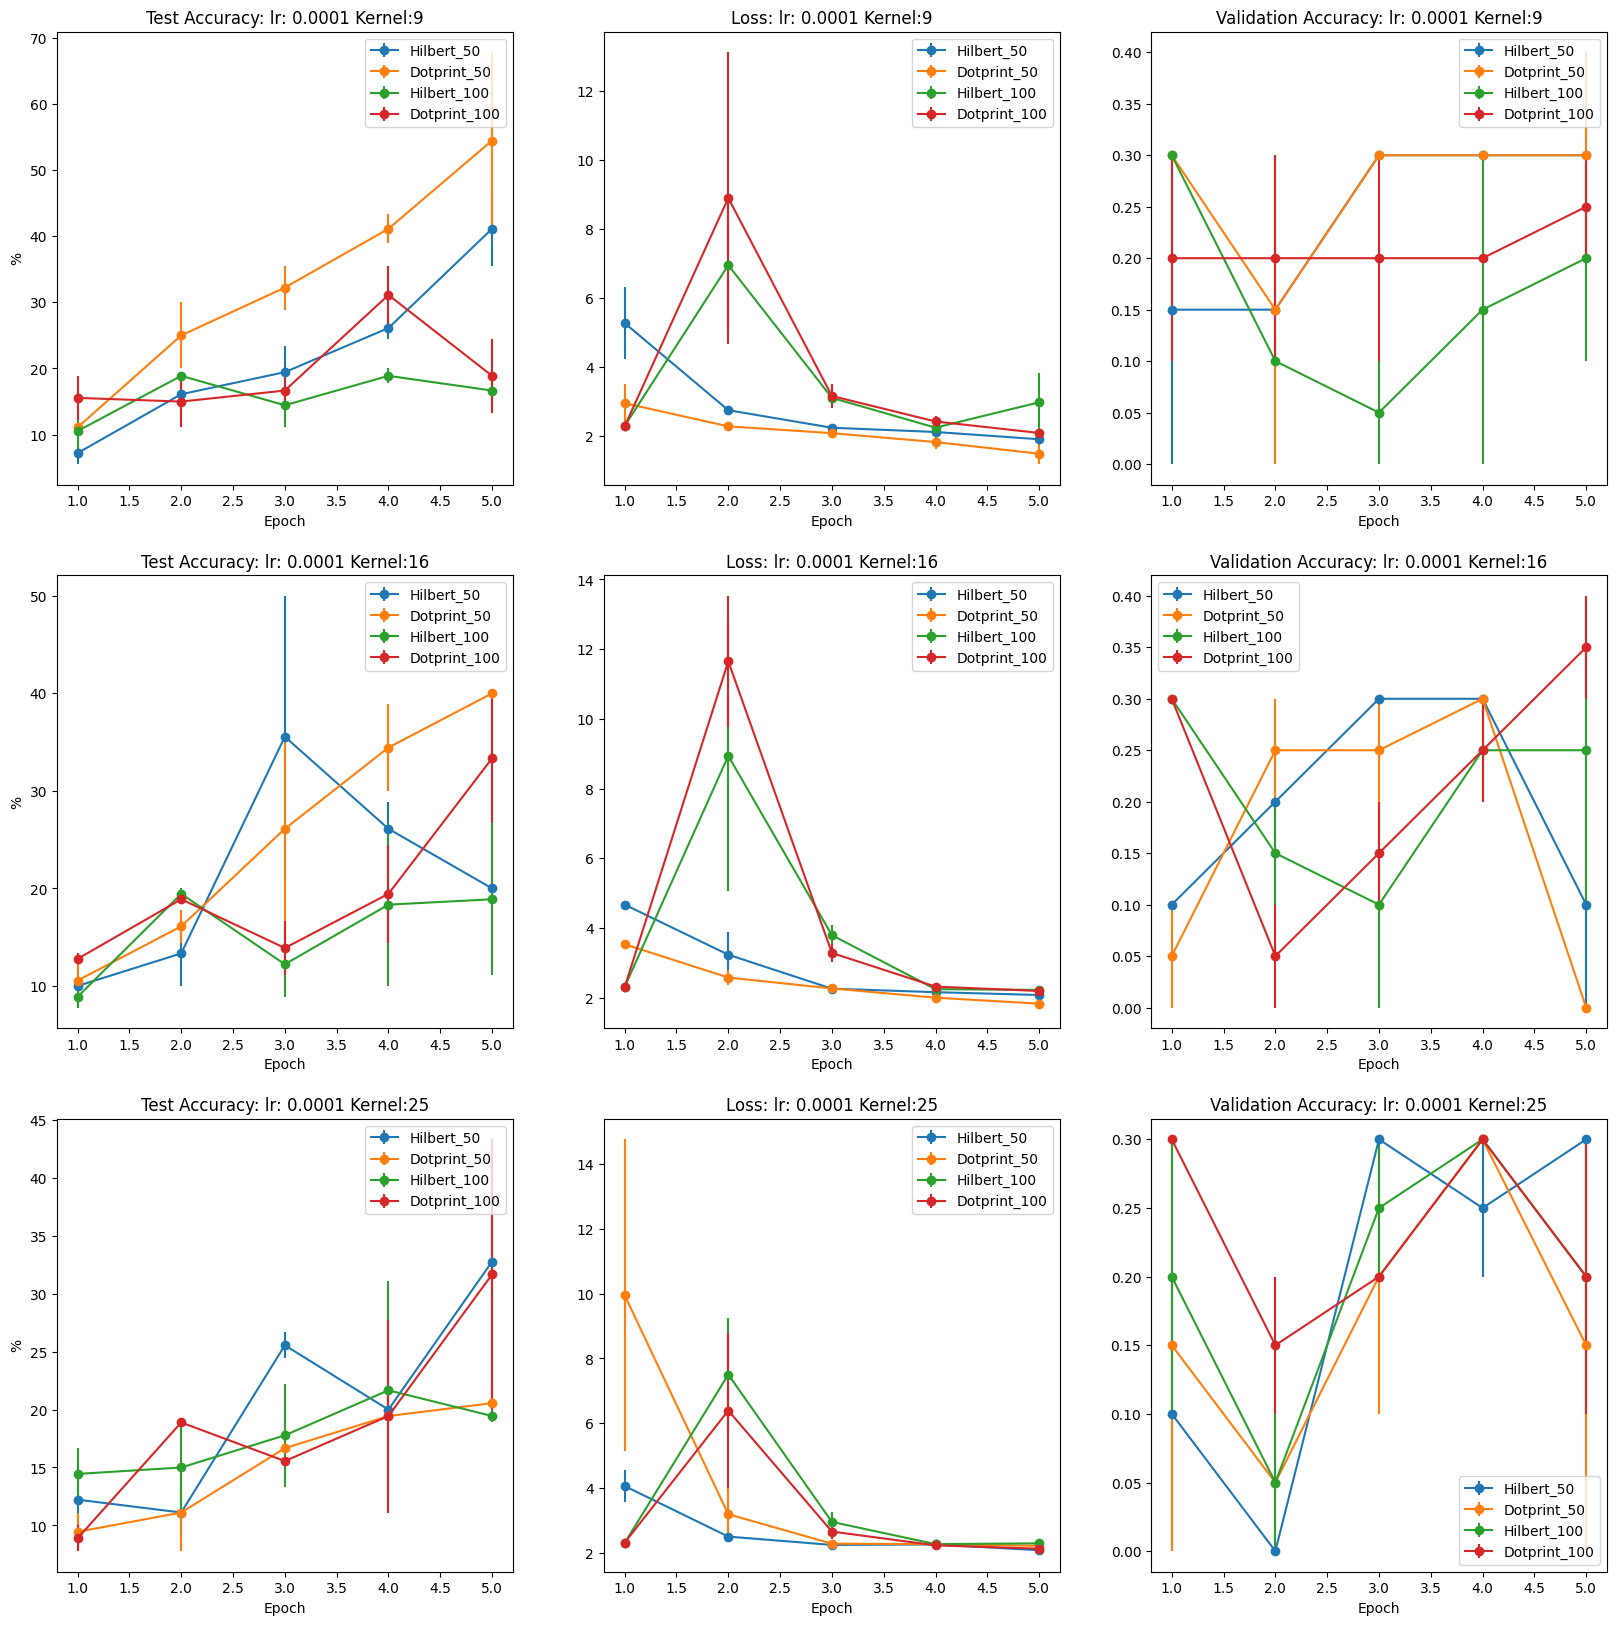

In [ ]:
import copy
import random 
import math
# import cv2

import tensorflow           as tf
import tensorflow_datasets  as tfds

import matplotlib.pyplot    as plt
import numpy                as np
import datetime             as dt

from IPython.display  import clear_output
from scipy.stats      import norm
from keras.utils      import np_utils

from hilbertcurve.hilbertcurve import HilbertCurve
import os
import pickle

from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten
from keras.layers import Conv1D,MaxPooling1D,Conv2D,MaxPooling2D
from keras.utils  import plot_model

import keras.backend as k

#############################
## Start of administration ##
#############################

tf.test.gpu_device_name()

startdate = dt.datetime.now()
timestamp = startdate.strftime('%d%m_%H%M%S')

# os.chdir('/Hilbert_AppliedIntelligence/')
# os.mkdir('Results_'+timestamp)
# os.chdir('Results_'+timestamp)

##########################
## Function Declaraions ##
##########################

def max_index(myarray):
    myindex = np.where(myarray==max(myarray))[0][0]
    return myindex

def Hilbert_map(dimension,iteration):
    length = pow(dimension,iteration)
    set_length = pow(length,dimension)
    my_curve = HilbertCurve(iteration,dimension)

    my_mapping = {}
    for x in range(length):
        for y in range(length):
            my_mapping[x,y] = my_curve.distance_from_point([x,y])

    return my_mapping

def Hilbert_reverse_map(dimension,iteration):
    my_map = np.empty((set_length,2),dtype=int)
    for i in range(set_length):
        point_index = my_curve.point_from_distance(i)
        my_map[i]=point_index

def Hilbert_collection(image_set,dimension,iteration):
    # get mapping sequence:
    my_Hilbert_transformation = Hilbert_map(dimension,iteration)
    transformed_image = np.empty((image_set[0].shape[0]*image_set.shape[1],image_set[0].shape[-1]))
    transformed_set = np.empty((image_set.shape[0],transformed_image.shape[0],transformed_image.shape[-1]))

    im_iterator = 0
    start_time = dt.datetime.now()
    im_set_length = len(image_set)

    for image in image_set:
        # process_time(start_time,im_iterator,im_set_length)
        for row in range(image.shape[0]):
            for column in range(image.shape[1]):
                my_pixel_values = image[row][column]
                my_hilbert_index = my_Hilbert_transformation[row,column]
                transformed_image[my_hilbert_index] = my_pixel_values
        transformed_set[im_iterator] = transformed_image
        im_iterator += 1
    return transformed_set

# Dotprint (original reshape) --->>> !!!!! Change to Flatten operation for performance
def dotprint_2Dto1D(dataset):
    iterator = 0
    if len(dataset.shape) > 3:
        mydata = np.empty((dataset.shape[0],dataset.shape[1]*dataset.shape[2],dataset.shape[3]))
    else:
        mydata = np.empty((dataset.shape[0],dataset.shape[1]*dataset.shape[2]))
        iterator = 0
    for mysample in dataset:
        newsample = list()
        for row in mysample:
            for col in row:
                newsample.append(col)
        mydata[iterator] = newsample
        iterator += 1
    return mydata

 # Try making this through the build-in function for padding but do not use the symmetric form

def zero_padding(mydata,size):
    mypadset = copy.deepcopy(mydata)
    if len(mydata.shape) > 3:
        finaldata = np.empty((mydata.shape[0],size,size,mydata.shape[3]))
    else:
        finaldata = np.empty((mydata.shape[0],size,size))
    
    # get the parameters for the transformation
    print("shape of the input data:",mypadset.shape)
    mysample = mypadset[0]
    ori_rows = mysample.shape[0]
    ori_cols = mysample.shape[1]
    
    print("original size of the input is",ori_cols,"x",ori_rows)
    iterator = 0
    if size > ori_rows and size > ori_cols:
        top         = int((size - ori_rows)/2)
        bottom      = int((size - ori_rows)/2)
        left        = int((size - ori_cols)/2)
        right       = int((size - ori_cols)/2)
        print("adding ((",top,",",bottom,"),(",left,",",right,"))")
        for mysample in mypadset:
            newsample = np.pad(mysample,((top,bottom),(left,right)),'constant')
            finaldata[iterator] = newsample
            iterator += 1
    elif size == ori_rows and size == ori_cols:
        print("No padding required as the image is already of proper size")
    else:
        print("The input image has dimensions larger than the intended size")
        
    print("shape of the input data after transformation:",finaldata.shape)
    return finaldata

#############################
## Start Data Processing   ##
############################# 
class_labels =['tench','English springer','cassette player','chain saw','church','French horn','garbage truck','gas pump','golf ball','parachute']
nb_classes = len(class_labels)

identifier= 'Imagenette_Classification'
filename  = identifier+"_"+timestamp+'.log'

batch_size = 64
train_range = 100
test_range = 20

####################
## Data loading #######################
## Can be replaced by prepared files ## 
#######################################

imagenette_builder = tfds.builder("imagenette/160px")
imagenette_info = imagenette_builder.info

imagenette_builder.download_and_prepare()
datasets = imagenette_builder.as_dataset(as_supervised=True)

train_examples = imagenette_info.splits['train'].num_examples
validation_examples = imagenette_info.splits['validation'].num_examples

print("Training: %i available -> %i loaded" %(train_examples, train_range))
print("Test: %i available -> %i loaded" %(validation_examples, test_range))

train_examples = min(train_examples,train_range)
validation_examples = min(validation_examples,test_range)

im_size = 128
training_map = datasets["train"].map(lambda image,label: (tf.image.resize(image,(im_size,im_size)),label)).take(train_range)
test_map = datasets["validation"].map(lambda image, label: (tf.image.resize(image, (im_size, im_size)), label)).take(test_range)

rgb_dim = 3

# training_image = np.empty((train_examples,im_size,im_size,rgb_dim))
# training_label = np.empty((len(training_map),1))

training_image = np.array([element[0]/256 for element in training_map])
training_label = np.array([element[1] for element in training_map])


validation_image = np.array([element[0]/256 for element in test_map])
validation_label = np.array([element[1] for element in test_map])

plt.imshow(training_image[5])
print(training_label[5],class_labels[int(training_label[5])])

# Shape of the training data
x_shape = training_image.shape
y_shape = training_label.shape
x_dimx = list(training_image.shape)[1]
x_dimy = list(training_image.shape)[2]

print("Input training data has shape:",x_shape, "and targets have shape:",y_shape)

my_dimension = 2
my_iteration = 7


x_train = training_image.reshape(training_image.shape[0],training_image.shape[1],training_image.shape[2],training_image.shape[-1])
x_test = validation_image.reshape(validation_image.shape[0],validation_image.shape[1],validation_image.shape[2],validation_image.shape[-1])

# Transform the labels properly
training_label = np_utils.to_categorical(training_label,nb_classes)
validation_label = np_utils.to_categorical(validation_label,nb_classes)

# Transform the datasets to linearized versions
myHilbertset  = Hilbert_collection(copy.deepcopy(x_train),my_dimension,my_iteration) 
myDotprintset = dotprint_2Dto1D(copy.deepcopy(x_train))

# Transform the test data:
myHilberttest  = Hilbert_collection(copy.deepcopy(x_test),my_dimension, my_iteration) 
myDotprinttest = dotprint_2Dto1D(copy.deepcopy(x_test))

# Remove images for RAM and memory preservation
del(imagenette_builder)
del(datasets)
del(training_map)

del(x_train)
del(x_test)
del(training_image)
del(validation_image)

# Create the dataset for each transformation
my_datasets = {}
my_datasets["Training"] = {}
my_datasets["Validation"] = {}

my_training_sets = {}
my_training_sets["Data"] = {}

my_validation_sets = {}
my_validation_sets["Data"] = {}
my_validation_sets["Label"] = {}


my_training_sets["Data"]["Hilbert"]  = myHilbertset
my_training_sets["Data"]["Dotprint"] = myDotprintset
my_training_sets["Label"] = training_label

my_validation_sets["Data"]["Hilbert"] = myHilberttest
my_validation_sets["Data"]["Dotprint"] = myDotprinttest
my_validation_sets["Label"] = validation_label

my_datasets["Training"] = my_training_sets
my_datasets["Validation"] = my_validation_sets

#######################################
## Model definition and construction ##
#######################################

filtersize_1d_small = 16
filtersize_1d_medium= 32
filtersize_1d_large = 64

kernelsize_1d_small = 4
kernelsize_1d_lowmed= 9
kernelsize_1d_medium= 16
kernelsize_1d_large = 25

filtersize_2d_small = 16
filtersize_2d_medium= 32
filtersize_2d_large = 64

kernelsize_2d_small = (2,2)
kernelsize_2d_medium= (4,4)
kernelsize_2d_large = (8,8)

input_shape_1d = myHilbertset.shape[1:]

optimizer  = 'adam'
activation = 'relu'
my_loss    = 'categorical_crossentropy'
mystride   = 1
mystride1  = 2

#### 1D Model setup:
def model1d(kernelsize): 
    model1d = Sequential()
    model1d.add(Conv1D(filtersize_1d_medium,kernelsize,strides=mystride,activation=activation,input_shape=input_shape_1d))
    model1d.add(Conv1D(filtersize_1d_large,kernelsize_1d_medium,strides=mystride,activation=activation))
    model1d.add(MaxPooling1D(4))
#    model1d.add(Dropout(0.25))
    
    model1d.add(Conv1D(filtersize_1d_medium,kernelsize,strides=mystride,activation=activation))
    
    model1d.add(Flatten())

    ## Is the additional dense layer an added value?
    model1d.add(Dense(64,activation=activation))
    model1d.add(Dense(nb_classes,activation='softmax'))
   
    return model1d
    
#### Fully connected 1D model:
def model1d_FCNN():
    model1d = Sequential()
    model1d.add(Dense(filtersize_1d_small,activation='relu',input_shape=input_shape_1d))
    model1d.add(Dense(filtersize_1d_medium,activation='relu'))
    
    model1d.add(Dropout(0.25))
    
    model1d.add(Dense(filtersize_1d_medium,activation='relu'))
    model1d.add(Dense(filtersize_1d_large,activation='relu'))
    model1d.add(Dropout(0.25))

    model1d.add(Flatten())
    
    model1d.add(Dense(256,activation=activation))
    model1d.add(Dense(nb_classes,activation='softmax'))
    
    return model1d
    

# Decrease dataset size for dummy training
setsize    = train_examples 

# Hyperparameters
nb_epoch = 5 
nb_runs = 2
my_lr = 0.0001
kernelsizes = [kernelsize_1d_lowmed,kernelsize_1d_medium,kernelsize_1d_large]
nb_batch = [50,100]
val_len = 10

##########################
## Start Model Training ##
##########################
# For each run we train the model and get the evolution of the training (accuracy,loss/epoch)
model_start_run = dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
progress_it = 0
print("model run started on", model_start_run)

myaccuracy = {} 
myloss = {}
val_myaccuracy={}
val_myloss={}

for my_kernel in kernelsizes:
  myaccuracy[my_kernel] = {}
  myloss[my_kernel] = {}
  val_myaccuracy[my_kernel]={}
  val_myloss[my_kernel]={}
  for my_batch in nb_batch:
    myaccuracy[my_kernel][my_batch] = {}
    myloss[my_kernel][my_batch] = {}
    val_myaccuracy[my_kernel][my_batch]={}
    val_myloss[my_kernel][my_batch]={}
    for key in list(my_datasets[ "Training"]['Data'].keys()):
        myaccuracy[my_kernel][my_batch][key] = {}
        myloss[my_kernel][my_batch][key] = {}
        val_myaccuracy[my_kernel][my_batch][key]={}
        val_myloss[my_kernel][my_batch][key]={}

process_times = []

randomseed = random.randint(0,(my_dimension**my_iteration)**2 - setsize)
ytrain = training_label

run_counter = 0
total_runs = len(kernelsizes)*len(nb_batch)*nb_runs*len(list(my_datasets["Training"]["Data"].keys()))

for my_kernel in kernelsizes:
  for my_batch in nb_batch:
    modelstart = dt.datetime.now()

    for i in range(nb_runs):
      
      for key in list(my_datasets["Training"]['Data'].keys()):
        run_start = dt.datetime.now()
        xtrain = my_datasets["Training"]['Data'][key][:-val_len]
        x_val = my_datasets["Training"]['Data'][key][-val_len:]
        
        ytrain = my_datasets['Training']['Label'][:-val_len]
        y_val = my_datasets['Training']['Label'][-val_len:]
        
        mymodel = model1d(my_kernel)

        clear_output(wait=True)
        print("Model run at %.2f" %(run_counter/total_runs*100),"%")

        mymodel.compile(optimizer='adam',loss=my_loss,metrics=['accuracy'])
        history = mymodel.fit(xtrain,ytrain,batch_size=my_batch,epochs=nb_epoch,verbose=0,validation_data=(x_val,y_val))

        myaccuracy[my_kernel][my_batch][key][i]=history.history['accuracy']
        myloss[my_kernel][my_batch][key][i]=history.history['loss']
        val_myaccuracy[my_kernel][my_batch][key][i]=history.history['val_accuracy']
        val_myloss[my_kernel][my_batch][key][i]=history.history['val_loss']

        k.clear_session()
        run_counter += 1

print("model run took",int((dt.datetime.now()-modelstart).total_seconds()),"seconds, finished",dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

my_feature_container = {}

my_feature_container["my_accuracy"]  = myaccuracy
my_feature_container["my_loss"] = myloss
my_feature_container["val_accuracy"] = val_myaccuracy
my_feature_container["val_loss"] = val_myloss


############################
## Store data and results ##
############################

# with open('Model_Data'+timestamp+'p', 'wb') as handle:
#     pickle.dump(my_feature_container, handle, protocol=pickle.HIGHEST_PROTOCOL)

fig = plt.figure(figsize=(20,20))

linestyles = ["solid","-","-."]
stylecounter = 0
nb_plots =3
plot_row = len(kernelsizes)
plot_it = 0

for my_kernel in kernelsizes:
    stylecounter = 0
    for my_batch in nb_batch:
        linestyle = linestyles[stylecounter]
        if stylecounter < len(linestyle)-1:
            stylecounter += 1
        else:
            stylecounter = 0
        for key in my_datasets["Training"]["Data"].keys():
            acc_means = np.empty((nb_epoch))
            acc_stds = np.empty((nb_epoch))
            loss_means = np.empty((nb_epoch))
            loss_stds = np.empty((nb_epoch))
            val_acc_means = np.empty((nb_epoch))
            val_acc_stds = np.empty((nb_epoch))
            for epoch in range(nb_epoch):
                acc_means[epoch],acc_stds[epoch] = norm.fit([myaccuracy[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
                loss_means[epoch],loss_stds[epoch] = norm.fit([myloss[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
                val_acc_means[epoch],val_acc_stds[epoch] = norm.fit([val_myaccuracy[my_kernel][my_batch][key][run][epoch] for run in range(nb_runs)])
            
            plt.subplot(plot_row,nb_plots,1+plot_it)
            im1 = plt.errorbar(range(1,nb_epoch+1),acc_means*100,acc_stds*100,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
            plt.title("Test Accuracy: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));plt.xlabel("Epoch");plt.ylabel("%");plt.legend()

            plt.subplot(plot_row,nb_plots,2+plot_it)
            im2 = plt.errorbar(range(1,nb_epoch+1),loss_means,loss_stds,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
            plt.title("Loss: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));
            plt.xlabel("Epoch");plt.ylabel("");plt.legend()

            plt.subplot(plot_row,nb_plots,3+plot_it)
            im2 = plt.errorbar(range(1,nb_epoch+1),val_acc_means,val_acc_stds,fmt='o',ls=linestyle,label=key+"_"+str(my_batch))
            plt.title("Validation Accuracy: lr: "+str(my_lr)+" Kernel:"+str(my_kernel));
            plt.xlabel("Epoch");plt.ylabel("");plt.legend()

    plot_it+=3

savefiles = 0
if savefiles:
    savedate = dt.datetime.now().strftime("%Y%m%d_%H%M")
    save_filename = identifier+"_10ksample_Seededmodel_lr_"+str(my_lr)+"_batch_"+str(nb_batch)+"_Filter_"+str(filtersize_1d_medium)+"Poolinglayer"+savedate+".png"
    print("Saving plot to",save_filename)
    plt.savefig(save_filename, bbox_inches='tight')